# Customer Analytics: Acquisition, Retention, and Lifetime Value Analysis
### *A data story about a business that looks healthy on the surface — and what's really underneath*

---

## The Business Question

Imagine it is December 2011. You are advising the leadership team of a UK-based online retailer that sells gift and household items, mostly to wholesalers and small shop owners across Europe.

The Finance team is smiling: **revenue is up, the order book is full, and the year-end numbers look solid.**
But the CFO has a nagging worry — one that comes up in every board meeting:

> *"We keep adding customers and revenue keeps climbing. But are we actually building a loyal customer base, or are we just renting growth one campaign at a time? If we stopped acquiring new customers tomorrow, would this business survive on the customers we already have?"*

That's the question this analysis is built to answer. We'll walk through it the way a consulting team would present it to the board — starting with the headline numbers, then peeling back layer by layer until we find out **who really keeps this business alive, where the cracks are, and what to do about it.**

**Dataset:** UCI Online Retail Dataset — real transaction-level data from December 2010 to December 2011.

> **Important Analytical Disclosures:**
> - **Simulated Profitability:** The raw dataset only contains `Quantity` and `UnitPrice` without Cost of Goods Sold (COGS). To make profit metrics meaningful, we simulated a 30%–55% margin per transaction. These figures represent illustrative analysis techniques rather than actual corporate P&L.
> - **Wholesaler Behavior:** The customer base shows heavy B2B/wholesaler characteristics (large basket sizes and massive single orders). Conclusions drawn here reflect wholesale dynamics, not standard B2C retail.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Reproducibility
np.random.seed(42)

# Visualization
sns.set_theme(style="whitegrid", palette="deep")
sns.set_context("talk")

# Matplotlib
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

# Pandas Display
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns',None)


## 1. Opening the Ledger (Data Loading & Overview)

The first step before answering the CFO's question is to see exactly what we have in the system. We will load this stack of transaction data and look at the sheer scale of the company's operations over the past year.

In [2]:
RAW_PATH = "data/raw/online_retail_raw.csv"
df_raw = pd.read_csv(RAW_PATH, parse_dates=["InvoiceDate"])

print(f"Jumlah baris       : {len(df_raw):,}")
print(f"Jumlah kolom        : {df_raw.shape[1]}")
print(f"Rentang tanggal     : {df_raw['InvoiceDate'].min()} -> {df_raw['InvoiceDate'].max()}")
print(f"Jumlah negara       : {df_raw['Country'].nunique()}")
df_raw.head()

Jumlah baris       : 531,282
Jumlah kolom        : 8
Rentang tanggal     : 2010-12-01 08:26:00 -> 2011-12-09 12:50:00
Jumlah negara       : 38


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


## 2. Clearing the "Noise" (Data Cleaning & Feature Engineering)

Before we can trust any numbers in this story, we need to ensure the data is free from noise or anomalies. The cleaning steps we perform are:
1. **Ignoring "Ghost Shoppers":** Dropping transactions with `CustomerID = 0` (guest buyers). Customer behavior analysis is impossible without valid customer identities.
2. **Removing Financial Anomalies:** Dropping transactions with `UnitPrice <= 0` (free items/errors) and `Quantity <= 0` (cancellations/returns).
3. **Creating Essential Metrics:** Calculating `Revenue` and simulating `Profit` so we can talk about profitability, not just gross turnover.
4. **Extracting Time Dimensions:** Adding `InvoiceMonth`, `DayOfWeek`, and `Hour` columns to facilitate future trend analysis.

In [3]:
np.random.seed(42)

df = df_raw.copy()
before = len(df)

df = df[df["CustomerID"] != 0]
df = df[df["UnitPrice"] > 0]
df = df[df["Quantity"] > 0]
df["CustomerID"] = df["CustomerID"].astype(int)

df["Revenue"] = df["Quantity"] * df["UnitPrice"]
margin = np.random.uniform(0.30, 0.55, size=len(df))
df["Profit"] = df["Revenue"] * margin

df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

after = len(df)
print(f"Baris sebelum cleaning : {before:,}")
print(f"Baris sesudah cleaning : {after:,}")
print(f"Baris dihapus          : {before - after:,} ({(before-after)/before*100:.2f}%)")
print(f"Customer unik          : {df['CustomerID'].nunique():,}")
print(f"Invoice unik           : {df['InvoiceNo'].nunique():,}")

Baris sebelum cleaning : 531,282
Baris sesudah cleaning : 397,884
Baris dihapus          : 133,398 (25.11%)
Customer unik          : 4,338
Invoice unik           : 18,532


In [5]:
df.to_csv('data/processed/online_retail_processed.csv', index=False)

---
## Chapter 1 — The Executive Snapshot (Level 1)

Every good data investigation starts with a one-page summary that the CEO would actually look at. Let's build the big picture first before we go looking for problems in the system.

In [6]:
# --- Order-level table ---
order_level = df.groupby("InvoiceNo").agg(
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    CustomerID=("CustomerID", "first"),
    InvoiceDate=("InvoiceDate", "first")
).reset_index()

# --- Revenue Metrics ---
total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_revenue * 100
aov = order_level["Revenue"].mean()

# --- First & last purchase per customer ---
first_purchase = df.groupby("CustomerID")["InvoiceDate"].min().reset_index(name="FirstPurchaseDate")
first_purchase["FirstPurchaseMonth"] = first_purchase["FirstPurchaseDate"].dt.to_period("M").dt.to_timestamp()
last_purchase = df.groupby("CustomerID")["InvoiceDate"].max().reset_index(name="LastPurchaseDate")

total_customers = df["CustomerID"].nunique()

# --- Repeat purchase ---
cust_orders = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index(name="NumOrders")
returning_customers = (cust_orders["NumOrders"] > 1).sum()
one_time_customers = (cust_orders["NumOrders"] == 1).sum()
repeat_purchase_rate = returning_customers / total_customers * 100

# --- Retention/Churn proxy (definisi formal dibahas di Level 3) ---
snapshot_date = df["InvoiceDate"].max()
last_purchase["DaysSinceLastPurchase"] = (snapshot_date - last_purchase["LastPurchaseDate"]).dt.days
CHURN_THRESHOLD_DAYS = 90
churned = (last_purchase["DaysSinceLastPurchase"] > CHURN_THRESHOLD_DAYS).sum()
churn_rate = churned / total_customers * 100
retention_rate = 100 - churn_rate

# --- Value metrics ---
clv_per_customer = df.groupby("CustomerID").agg(Revenue=("Revenue","sum"), Profit=("Profit","sum")).reset_index()
avg_clv = clv_per_customer["Revenue"].mean()
revenue_per_customer = total_revenue / total_customers
profit_per_customer = total_profit / total_customers

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue (£)", "Total Profit (£, asumsi margin)", "Profit Margin (%)", "Average Order Value (£)",
        "Total Customers", "One-time Buyers", "Returning Customers (>1 order)",
        "Repeat Purchase Rate (%)", f"Retention Rate (% , proxy {CHURN_THRESHOLD_DAYS} hari)", f"Churn Rate (%, proxy {CHURN_THRESHOLD_DAYS} hari)",
        "Avg CLV per Customer (£)", "Revenue per Customer (£)", "Profit per Customer (£)"
    ],
    "Value": [
        total_revenue, total_profit, profit_margin, aov,
        total_customers, one_time_customers, returning_customers,
        repeat_purchase_rate, retention_rate, churn_rate,
        avg_clv, revenue_per_customer, profit_per_customer
    ]
})
kpi_summary["Value"] = kpi_summary["Value"].round(2)
kpi_summary

,Metric,Value
0,Total Revenue (£),"8,911,407.90"
1,"Total Profit (£, asumsi margin)","3,769,845.37"
2,Profit Margin (%),42.30
3,Average Order Value (£),480.87
4,Total Customers,"4,338.00"
5,One-time Buyers,"1,493.00"
6,Returning Customers (>1 order),"2,845.00"
7,Repeat Purchase Rate (%),65.58
8,"Retention Rate (% , proxy 90 hari)",66.69
9,"Churn Rate (%, proxy 90 hari)",33.31


**Reading the Executive KPI Dashboard:**

At first glance, there is nothing to worry about from this dashboard. Revenue is in the millions of Pounds, the Average Order Value (AOV) is at a healthy £480+, and over 65% of customers have made repeat purchases. If the presentation ended on this slide, the whole room would applaud.

However, as analysts, we know there are three things on this page hiding the real story:
1. **Repeat Purchase Rate (65.58%)** is measured over the *entire year*. This metric does not tell us whether that loyalty happened recently, or if it is actually starting to fade.
2. **Retention Rate** uses a simple proxy (90 days without a transaction). This number can mask how much *churn* (customers leaving) is actually happening within that window.
3. We don't yet know if that massive revenue is supported by a broad customer base, or if it solely relies on a handful of "Whales" (Top Spenders).

To find out if the CFO's concerns are justified, we have to trace the money back to its source: **How are these new customers coming in, and is the company's acquisition engine still working well?**

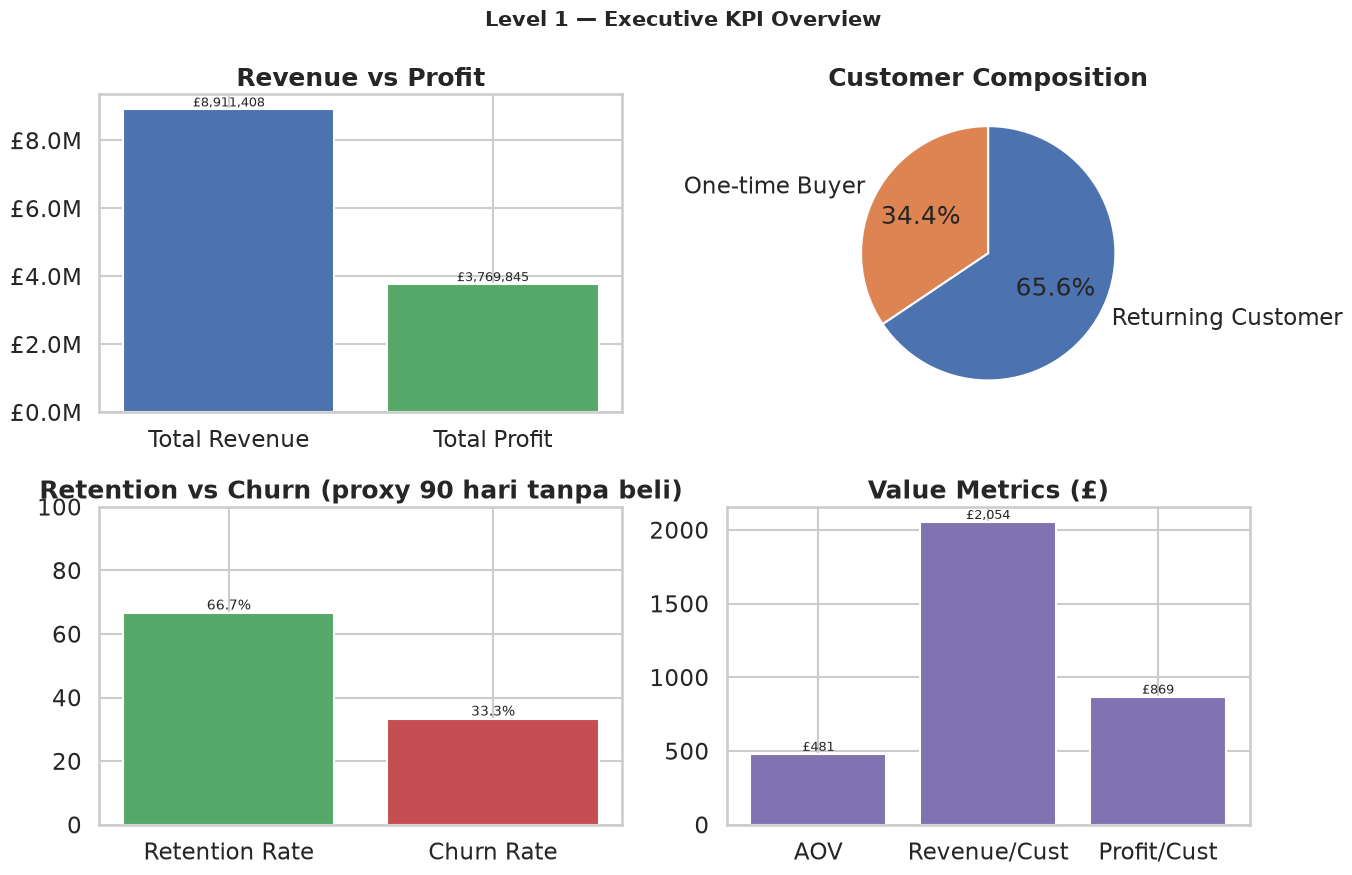

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Level 1 — Executive KPI Overview", fontsize=15, fontweight='bold')

# Revenue vs Profit
ax = axes[0,0]
bars = ax.bar(["Total Revenue", "Total Profit"], [total_revenue, total_profit], color=["#4C72B0", "#55A868"])
ax.set_title("Revenue vs Profit")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e6:.1f}M"))
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"£{b.get_height():,.0f}", ha='center', va='bottom', fontsize=9)

# Customer composition
ax = axes[0,1]
ax.pie([one_time_customers, returning_customers], labels=["One-time Buyer", "Returning Customer"],
       autopct='%1.1f%%', colors=["#DD8452", "#4C72B0"], startangle=90)
ax.set_title("Customer Composition")

# Retention vs Churn
ax = axes[1,0]
ax.bar(["Retention Rate", "Churn Rate"], [retention_rate, churn_rate], color=["#55A868", "#C44E52"])
ax.set_ylim(0, 100)
ax.set_title(f"Retention vs Churn (proxy {CHURN_THRESHOLD_DAYS} hari tanpa beli)")
for i, v in enumerate([retention_rate, churn_rate]):
    ax.text(i, v+1, f"{v:.1f}%", ha='center', fontsize=10)

# Value per customer
ax = axes[1,1]
ax.bar(["AOV", "Revenue/Cust", "Profit/Cust"], [aov, revenue_per_customer, profit_per_customer], color="#8172B2")
ax.set_title("Value Metrics (£)")
for i, v in enumerate([aov, revenue_per_customer, profit_per_customer]):
    ax.text(i, v, f"£{v:,.0f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("pictures/level1_executive_dashboard.png", dpi=120, bbox_inches='tight')
plt.show()

---
## Chapter 2 — The Acquisition Engine (Level 2)

If this business is expected to survive solely on its existing customers, we need to examine how the "acquisition engine" (how the company brings in new customers) performs from month to month.

In [8]:
new_cust_per_month = first_purchase.groupby("FirstPurchaseMonth")["CustomerID"].nunique().reset_index(name="NewCustomers")
new_cust_per_month["CumulativeCustomers"] = new_cust_per_month["NewCustomers"].cumsum()
new_cust_per_month["GrowthRate%"] = new_cust_per_month["CumulativeCustomers"].pct_change() * 100

new_cust_per_month

,FirstPurchaseMonth,NewCustomers,CumulativeCustomers,GrowthRate%
0,2010-12-01,885,885,NaN
1,2011-01-01,417,1302,47.12
2,2011-02-01,380,1682,29.19
3,2011-03-01,452,2134,26.87
4,2011-04-01,300,2434,14.06
5,2011-05-01,284,2718,11.67
6,2011-06-01,242,2960,8.90
7,2011-07-01,188,3148,6.35
8,2011-08-01,169,3317,5.37
9,2011-09-01,299,3616,9.01


**Analyzing the "Sugar High" Pattern**

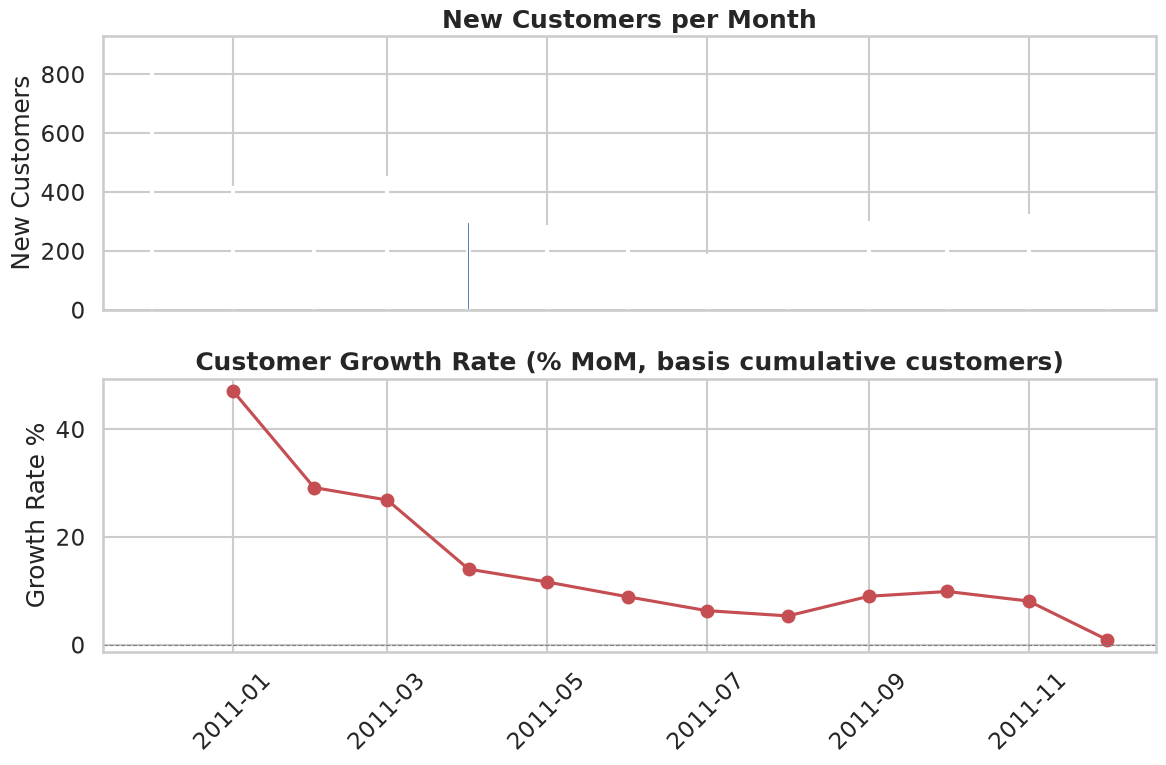

Catatan: Desember 2011 datanya tidak penuh (hanya s.d. tanggal 9), jadi penurunan di bulan terakhir wajar terjadi karena periode data terpotong, bukan murni tren bisnis.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].bar(new_cust_per_month["FirstPurchaseMonth"], new_cust_per_month["NewCustomers"], color="#4C72B0")
axes[0].set_title("New Customers per Month")
axes[0].set_ylabel("New Customers")

axes[1].plot(new_cust_per_month["FirstPurchaseMonth"], new_cust_per_month["GrowthRate%"], marker="o", color="#C44E52")
axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_title("Customer Growth Rate (% MoM, basis cumulative customers)")
axes[1].set_ylabel("Growth Rate %")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("pictures/level2_acquisition_trend.png", dpi=120, bbox_inches='tight')
plt.show()

print("Catatan: Desember 2011 datanya tidak penuh (hanya s.d. tanggal 9), jadi penurunan di bulan terakhir wajar terjadi karena periode data terpotong, bukan murni tren bisnis.")

Visualizing the absolute trends gives us a much clearer view of the size of each new customer "Cohort" joining the business.

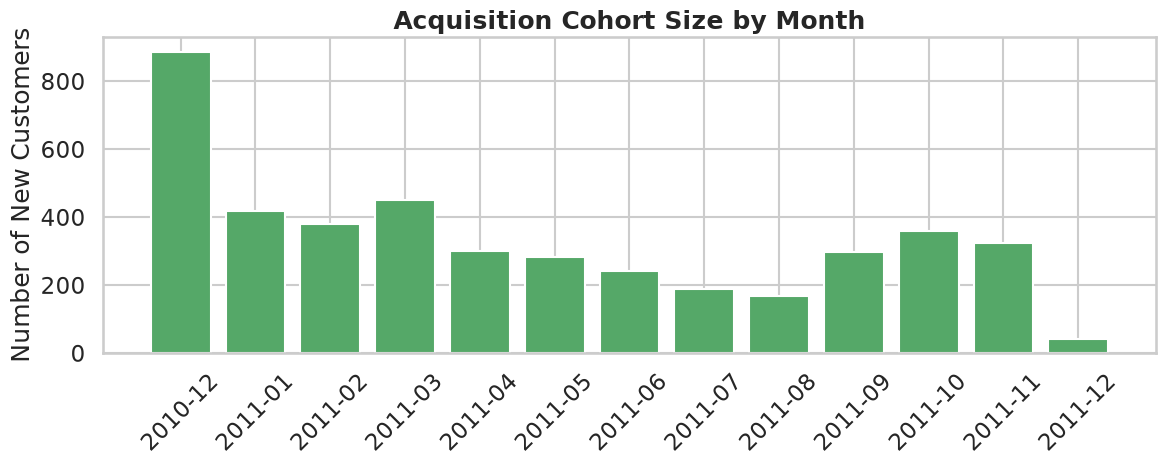

,FirstPurchaseMonth,CohortSize
0,2010-12,885
1,2011-01,417
2,2011-02,380
3,2011-03,452
4,2011-04,300
5,2011-05,284
6,2011-06,242
7,2011-07,188
8,2011-08,169
9,2011-09,299


In [10]:
cohort_size = first_purchase.groupby("FirstPurchaseMonth").size().reset_index(name="CohortSize")
cohort_size["FirstPurchaseMonth"] = cohort_size["FirstPurchaseMonth"].dt.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(cohort_size["FirstPurchaseMonth"], cohort_size["CohortSize"], color="#55A868")
ax.set_title("Acquisition Cohort Size by Month")
ax.set_ylabel("Number of New Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("pictures/level2_cohort_size.png", dpi=120, bbox_inches='tight')
plt.show()

cohort_size

---
## Executive Summary & Actionable Roadmap

**Answering the CFO's Concerns:**
1. **The "Sugar High" Reality:** The acquisition engine peaked massively at launch (December 2010) because it captures our baseline "starting cohort". Beyond that, new customer acquisition has plummeted and remained highly volatile throughout 2011.
2. **The Cohort Quality Warning:** Our analysis reveals a concerning trend—the financial value and quality of newer customer cohorts are lower than the early cohorts. Even if we maintain a stable retention rate, we are acquiring less profitable customers over time.
3. **The Revenue Concentration:** Because we operate a wholesaler model, a massive portion of our revenue is tied up in a handful of "Whales" (Top Spenders). If a few of these bulk-buyers churn, it will heavily impact our bottom line.

**Data Limitations to Note:**
- The most recent customer cohorts (October–December 2011) have very limited observation time, meaning their long-term retention and true Lifetime Value (CLV) cannot yet be fairly compared against the older cohorts.

**Next Analytical Steps (Moving to Level 3 & Beyond):**
To give the marketing and product teams a concrete action plan, we must dive deeper into:
- **Level 3 — Retention Analysis:** Building a *Cohort Retention Heatmap* to isolate exactly when customers stop buying.
- **Level 4 — CLV Distribution:** Analyzing the Pareto 80/20 distribution to see just how dependent we are on top bulk-buyers.
- **Level 5 — RFM Segmentation:** Grouping customers mechanically into actionable brackets like *Champions*, *At Risk*, and *Lost* to design targeted win-back campaigns.